In [ ]:
import numpy as np

# siatka spinów 2D, gdzie każdy spin może przyjmować wartość +1 lub -1
def init_lattice(N):
    return np.random.choice([-1, 1], size=(N, N))

def delta_E(spins, i, j, J, B):
    N = spins.shape[0]
    s = spins[i, j]

    nn = (#sumuje sąsiadów 4 na górze i dole oraz 4 na przekątnych
        spins[(i+1)%N, j] + spins[(i-1)%N, j] +
        spins[i, (j+1)%N] + spins[i, (j-1)%N] +
        spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N] +
        spins[(i-1)%N, (j+1)%N] + spins[(i-1)%N, (j-1)%N]
    )

    return 2 * s * (J * nn + B)

def magnetization(spins):
    return np.mean(spins)

def energy(spins, J, B):
    N = spins.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            s = spins[i, j]
            nn = (
                spins[(i+1)%N, j] + spins[i, (j+1)%N] +
                spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N]
            )
            E += -J * s * nn - B * s
    return E

def simulate(N, M, J, B, beta, initial_spins=None):
    if initial_spins is None:
        spins = init_lattice(N)
    else:
        spins = initial_spins.copy()

    mags = []
    energies = []
    frames = []

    for step in range(M):
        for _ in range(N * N):
            i = np.random.randint(0, N)
            j = np.random.randint(0, N)

            dE = delta_E(spins, i, j, J, B)

            if dE < 0 or np.random.rand() < np.exp(-beta * dE):
                spins[i, j] *= -1

        mags.append(magnetization(spins))
        energies.append(energy(spins, J, B))

        frames.append(spins.copy())    
        return spins, np.array(mags), np.array(energies), frames


In [ ]:
from numba import njit
import numpy as np

@njit
def delta_E_numba(spins, i, j, J, B):
    N = spins.shape[0]
    s = spins[i, j]

    nn = (
        spins[(i+1)%N, j] + spins[(i-1)%N, j] +
        spins[i, (j+1)%N] + spins[i, (j-1)%N] +
        spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N] +
        spins[(i-1)%N, (j+1)%N] + spins[(i-1)%N, (j-1)%N]
    )

    return 2 * s * (J * nn + B)

@njit
def monte_carlo_macrostep(spins, J, B, beta):
    N = spins.shape[0]
    for _ in range(N * N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        dE = delta_E_numba(spins, i, j, J, B)
        if dE < 0 or np.random.rand() < np.exp(-beta * dE):
            spins[i, j] *= -1

@njit
def energy_numba(spins, J, B):
    N = spins.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            s = spins[i, j]
            nn = (
                spins[(i+1)%N, j] + spins[i, (j+1)%N] +
                spins[(i+1)%N, (j+1)%N] + spins[(i+1)%N, (j-1)%N]
            )
            E += -J * s * nn - B * s
    return E

@njit
def simulate_numba(spins, M, J, B, beta):
    mags = np.empty(M, np.float64)
    energies = np.empty(M, np.float64)

    for step in range(M):
        monte_carlo_macrostep(spins, J, B, beta)
        mags[step] = np.mean(spins)
        energies[step] = energy_numba(spins, J, B)

    return mags, energies

def simulate_numba_wrapper(N, M, J, B, beta, initial_spins=None):
    if initial_spins is None:
        spins = np.random.choice([-1, 1], size=(N, N))
    else:
        spins = initial_spins.copy()

    mags, energies = simulate_numba(spins, M, J, B, beta)
    return spins, mags, energies

def simulate_numba_with_frames(N, M, J, B, beta, initial_spins=None):
    if initial_spins is None:
        spins = np.random.choice([-1, 1], size=(N, N))
    else:
        spins = initial_spins.copy()

    mags = []
    energies = []
    frames = []

    for step in range(M):
        monte_carlo_macrostep(spins, J, B, beta)
        mags.append(np.mean(spins))
        energies.append(energy_numba(spins, J, B))
        frames.append(spins.copy())

    return spins, np.array(mags), np.array(energies), frames

In [ ]:
import time

N = 50
M = 100
J = 1.0
B = 0.0
beta = 0.4

np.random.seed(1234)
initial_spins = np.random.choice([-1, 1], size=(N, N))


start = time.time()print(f"Final Numba magnetization: {mags_nb[-1]:.4f}")

spins_py, mags_py, energies_py, frames_py = simulate(print(f"Final Python magnetization: {mags_py[-1]:.4f}")

    N=N, M=M, J=J, B=B, beta=beta, initial_spins=initial_spinsprint(f"Numba version elapsed: {numba_time:.4f} s")

)print(f"Numba compile overhead: {compile_time:.4f} s")

python_time = time.time() - startprint(f"Python version elapsed: {python_time:.4f} s")



spins_nb = initial_spins.copy()numba_time = time.time() - start

compile_start = time.time()mags_nb, energies_nb = simulate_numba(spins_nb, M, J, B, beta)

simulate_numba(spins_nb, 1, J, B, beta)start = time.time()

compile_time = time.time() - compile_startspins_nb = initial_spins.copy()


Python: 3.6772613525390625
Numba: 0.015542030334472656


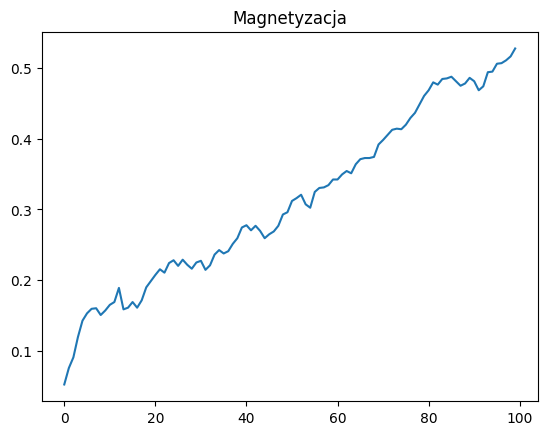

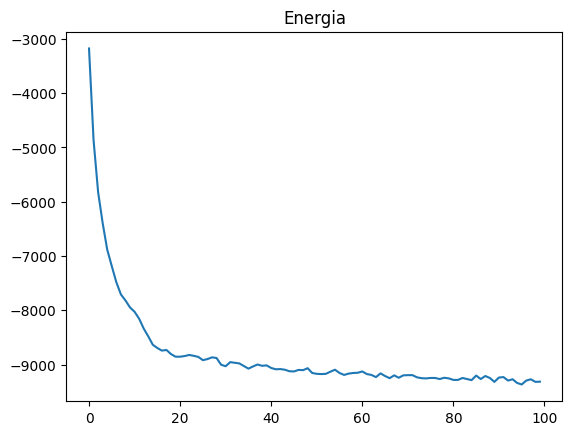

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(mags_py, label='Python')
plt.xlabel('Makrokrok')
plt.ylabel('Magnetyzacja')
plt.title('Magnetyzacja m(t)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(energies_py, label='Python')
plt.xlabel('Makrokrok')
plt.ylabel('Energia')
plt.title('Energia H(t)')
plt.grid(True)
plt.legend()
plt.show()

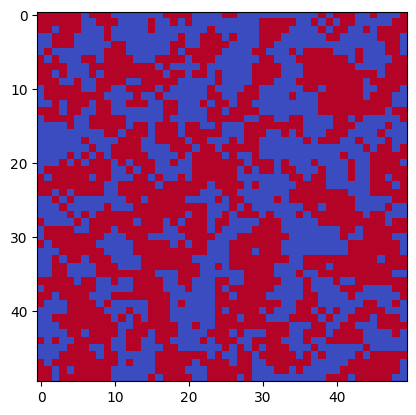

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames_py[0], cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Ewolucja układu spinów')
ax.axis('off')

def update(frame):
    im.set_array(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames_py, interval=200, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())